# Quantum Key Distribution (Without Eavesdropper)

## Imports

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.primitives import BackendSamplerV2

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

## Quantum  Circuit

In [3]:
# Set up a random number generator and a quantum circuit. I choose to start with 20 bits, though any number <30 should be fine.

rng = np.random.default_rng()
bit_num = 20
qc = QuantumCircuit(bit_num, bit_num)

# QKD step 1: Random bits and bases for Alice
# generate Alice's random bits

abits = np.round(rng.random(bit_num))

# generate Alice's random measurement bases. Here we will associate a "0" with the Z basis, and a "1" with the X basis.

abase = np.round(rng.random(bit_num))

# Alice's state preparation. Check that this creates states according to table 1

for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)

qc.barrier()

# QKD step 2: Random bases for Bob
# generate Bob's random measurement bases.

bbase = np.round(rng.random(bit_num))

# Note that if Bob measures in Z no gates are necessary, since IBM Quantum computers measure in Z by default.
# If Bob measures in the X basis, we implement a hadamard gate qc.h to facilitate the measurement.

for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(m, m)

Alice's bits are  [1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1.]
Alice's bases are  [1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0.]
Bob's bases are  [0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0.]


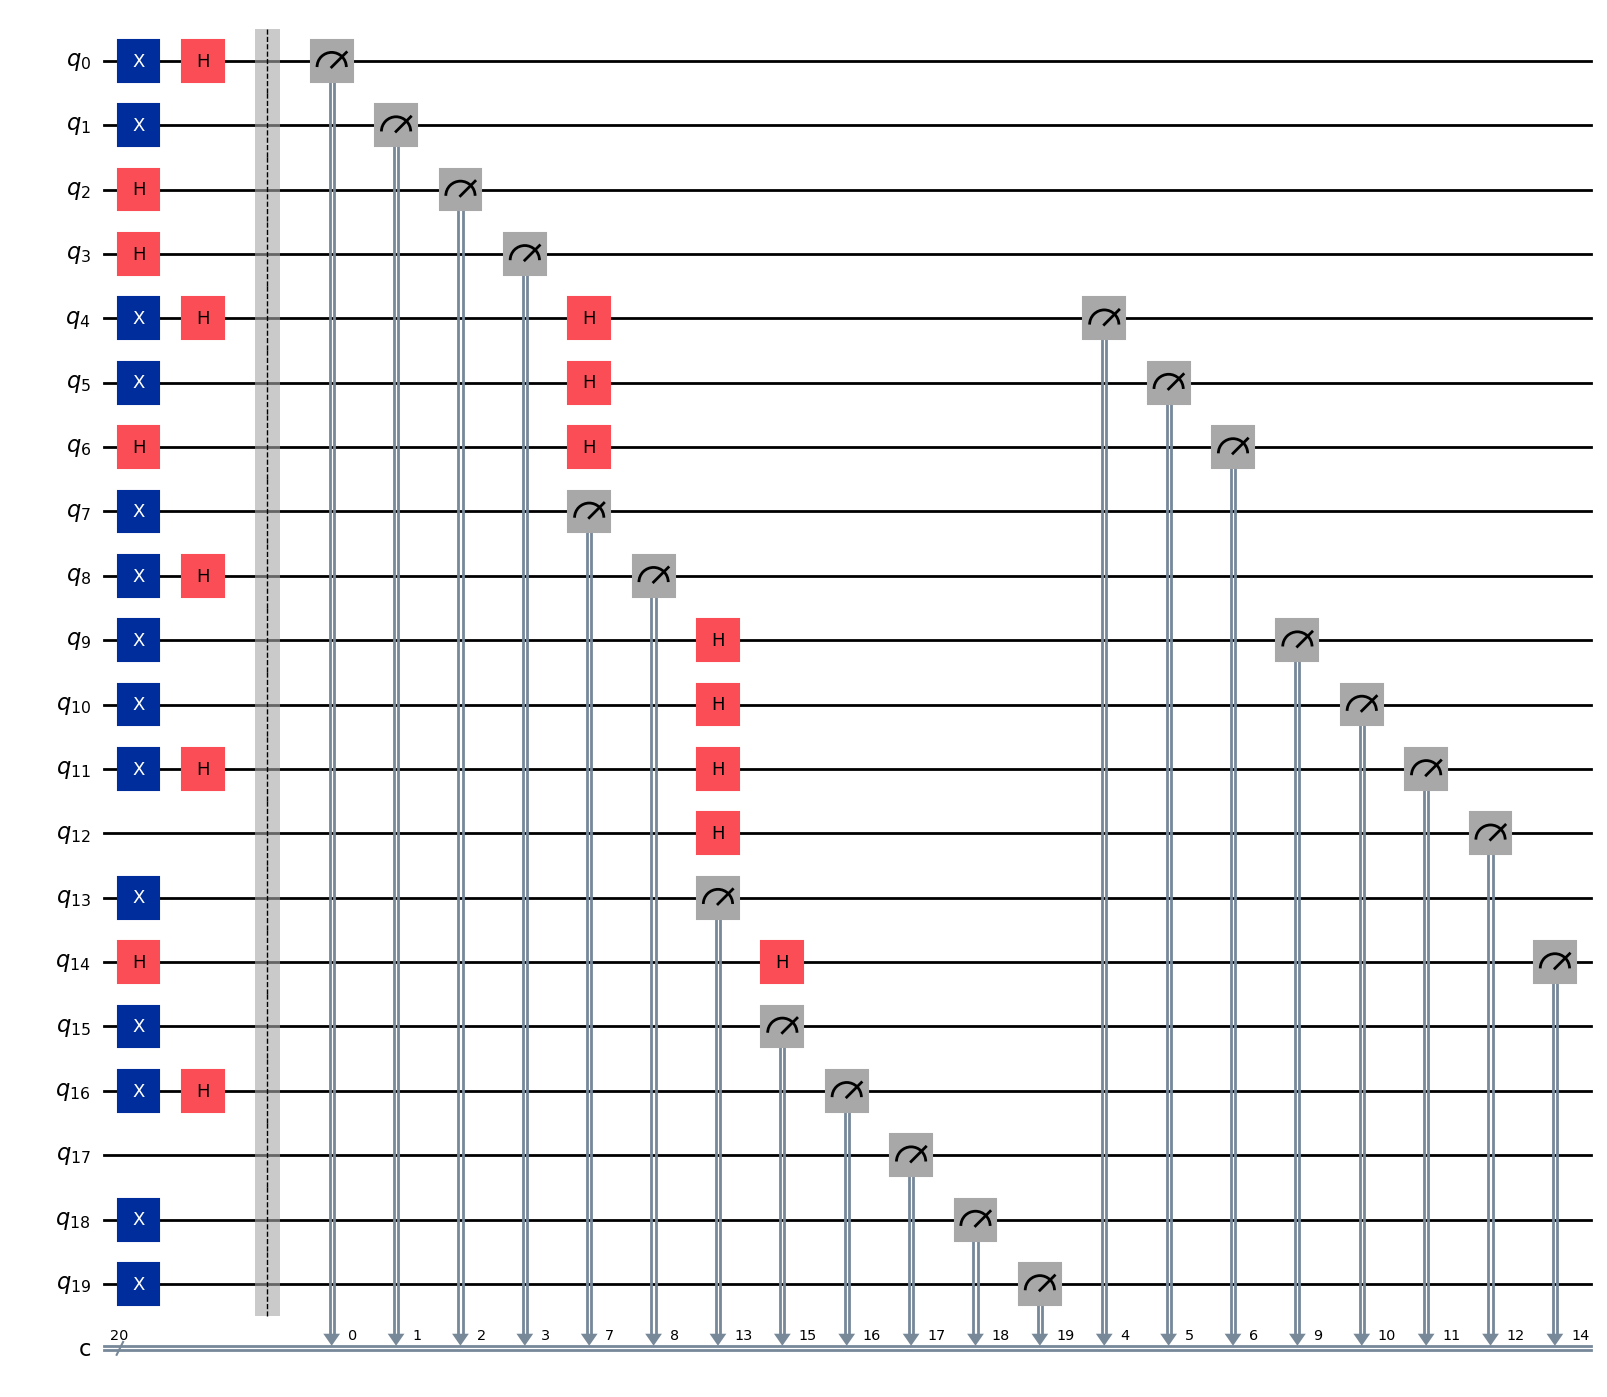

In [4]:
print("Alice's bits are ", abits)
print("Alice's bases are ", abase)
print("Bob's bases are ", bbase)
qc.draw("mpl")

## Optimize problem for quantum execution

In [5]:
# Load saved credentials
service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)

print(backend.name)

ibm_fez


In [6]:
noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [26]:
target = backend.target

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

## Execute

In [8]:
sampler = Sampler(mode=backend)
# job = sampler.run([qc_isa], shots=1)
job = sampler_sim.run([qc], shots = 1)
counts = job.result()[0].data.c.get_counts()
countsint = job.result()[0].data.c.get_int_counts()

##  Post-processing

In [9]:
# Get an array of bits

keys = counts.keys()
key = list(keys)[0]
bmeas = list(key)
bmeas_ints = []
for n in range(bit_num):
    bmeas_ints.append(int(bmeas[n]))

# Reverse the order to match our input. See "little endian" notation.

bbits = bmeas_ints[::-1]

print(bbits)

[0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1]


Let's compare the measurement bases randomly chosen by Alice and Bob. This was step 3 in our QKD protocol (public discussion of bases). Any time they chose the same basis for a qubit, we add the bits associated with that qubit to a list of bits for generating numbers in a one-time pad. When the bases do not match, the results are thrown out. Let us also check to see the two lists of bits agree, or if there were any losses due to noise or other factors.

In [10]:
# QKD step 3: Public discussion of bases

agoodbits = []
bgoodbits = []
match_count = 0
for n in range(bit_num):
    # Check whether bases matched.
    if abase[n] == bbase[n]:
        agoodbits.append(int(abits[n]))
        bgoodbits.append(bbits[n])
        # If bits match when bases matched, increase count of matching bits
        if int(abits[n]) == bbits[n]:
            match_count += 1

print(agoodbits)
print(bgoodbits)
print("fidelity = ", match_count / len(agoodbits))
print("loss = ", 1 - match_count / len(agoodbits))

[1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1]
[1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1]
fidelity =  1.0
loss =  0.0


# Quantum key Distribution With an eavesdropper

In [11]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

# Qiskit patterns step 1: Mapping your problem to a quantum circuit
# QKD step 1: Random bits and bases for Alice

bit_num = 20
qr = QuantumRegister(bit_num, "q")
cr = ClassicalRegister(bit_num, "c")
qc = QuantumCircuit(qr, cr)

# Alice's random bits and bases, as before

abits = np.round(rng.random(bit_num))
abase = np.round(rng.random(bit_num))

# Alice's state preparation, as before

for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)

qc.barrier()

# Eavesdropping happens here!
# Generate Eve's random measurement bases

ebase = np.round(rng.random(bit_num))

for m in range(bit_num):
    if ebase[m] == 1:
        qc.h(m)
    qc.measure(qr[m], cr[m])

In [16]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

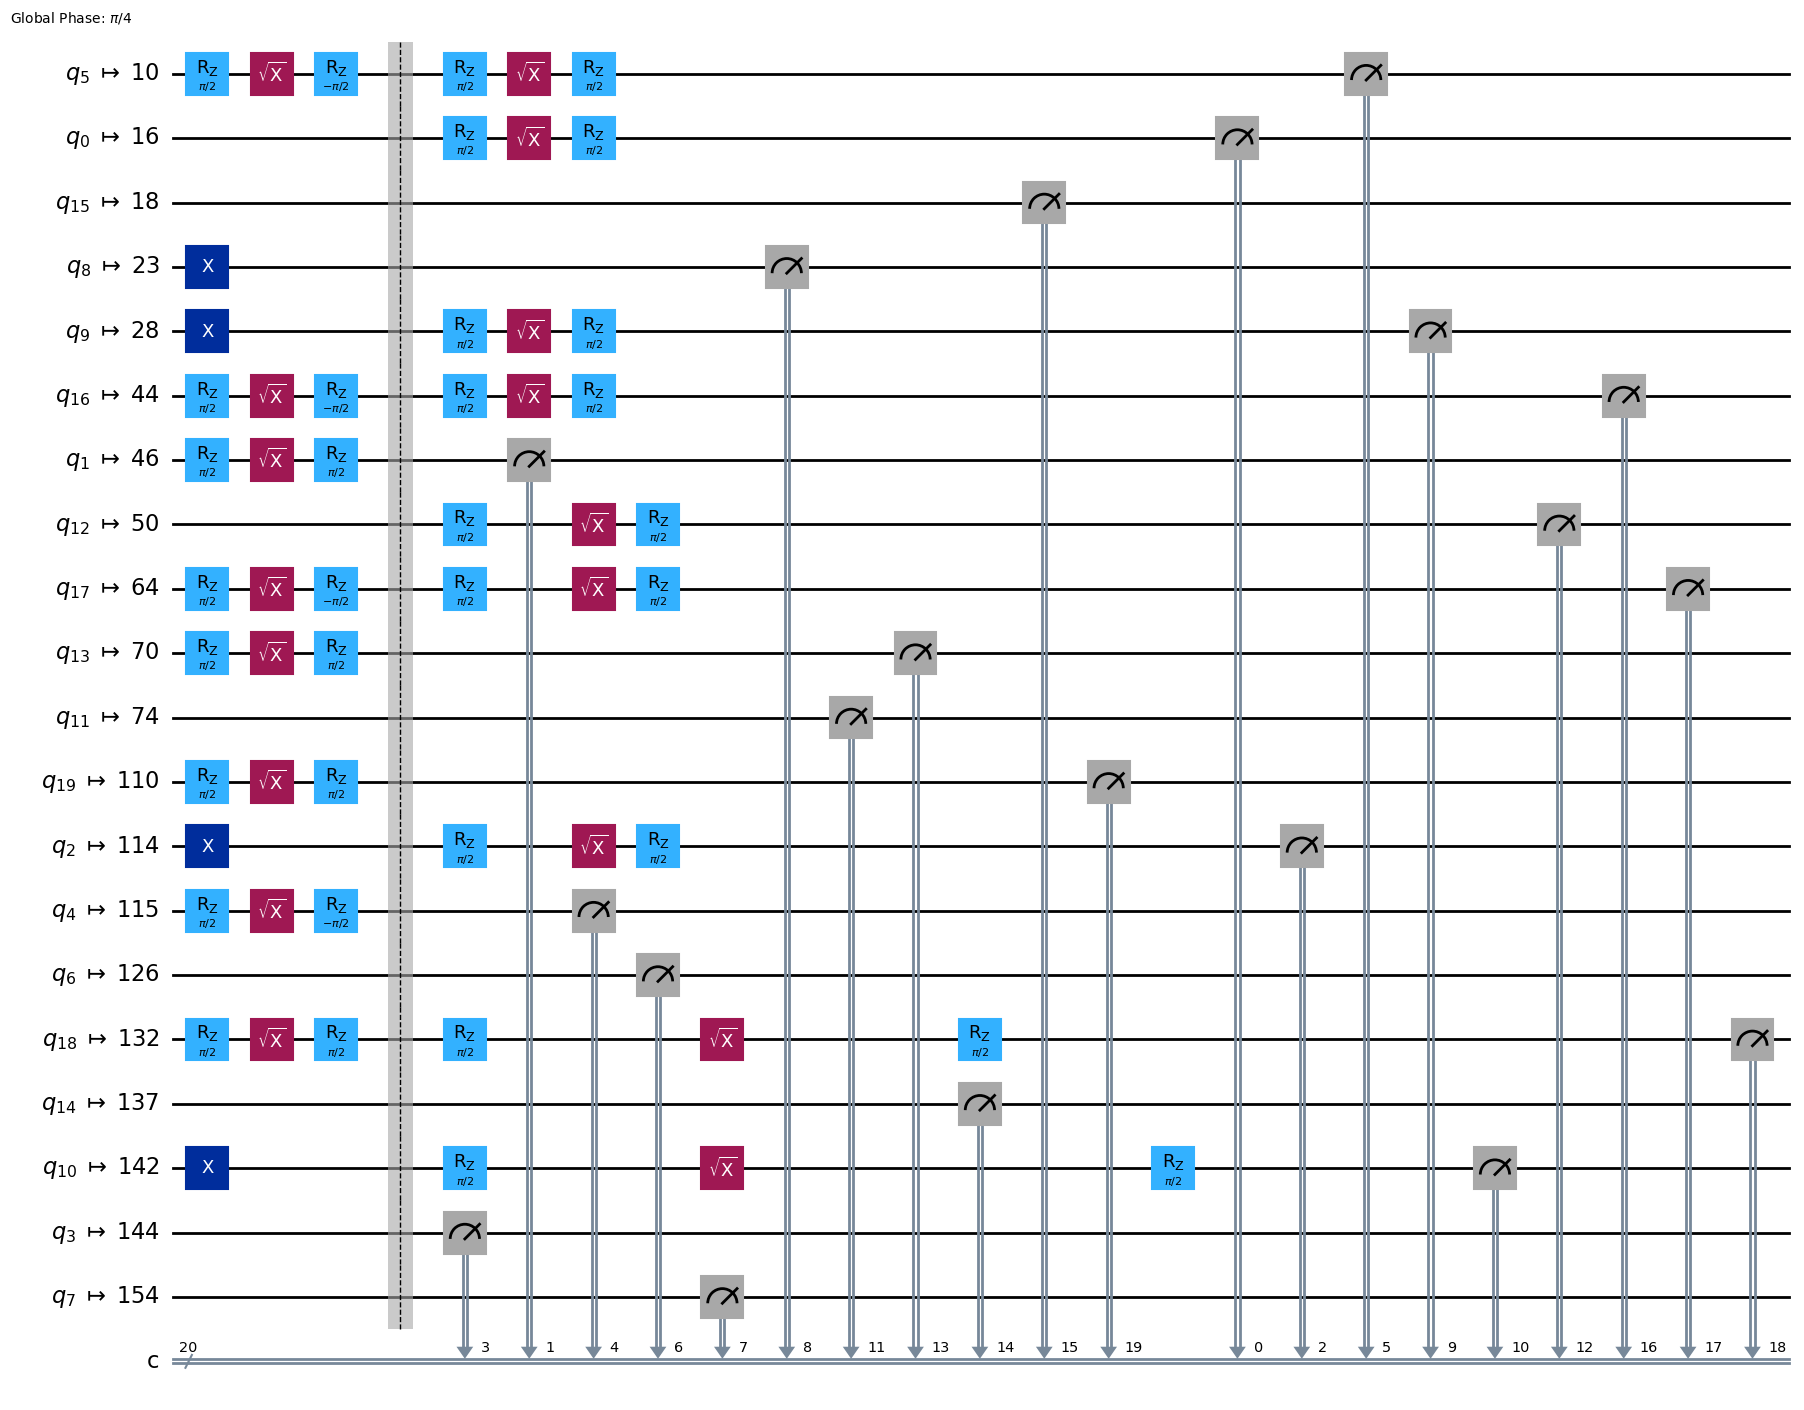

In [17]:
qc_isa.draw("mpl")

In [18]:
# Qiskit patterns step 3: Execute
job = sampler_sim.run([qc_isa], shots=1)
counts = job.result()[0].data.c.get_counts()
countsint = job.result()[0].data.c.get_int_counts()

Eve has the following bits:

In [19]:
keys = counts.keys()
key = list(keys)[0]
emeas = list(key)
emeas_ints = []
for n in range(bit_num):
    emeas_ints.append(int(emeas[n]))
ebits = emeas_ints[::-1]

print(ebits)

[1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1]


Now Eve must reconstruct states to send on to Bob.
She could assume every basis choice was correct and encode exactly what she measured, or she could assume she chose the basis incorrectly and choose either eigenstate of the opposite basis. Here, we assume the former, for simplicity. We accomplish this by constructing a whole new quantum circuit, repeating Qiskit patterns steps as before.

In [20]:
# Qiskit patterns step 1: Mapping your problem onto a quantum circuit
# QKD step 1: Eve uses her measurements to prepare best guess states to send on to Bob

qr = QuantumRegister(bit_num, "q")
cr = ClassicalRegister(bit_num, "c")
qc = QuantumCircuit(qr, cr)

# Eve's state preparation

for n in range(bit_num):
    if ebits[n] == 0:
        if ebase[n] == 1:
            qc.h(n)
    if ebits[n] == 1:
        if ebase[n] == 0:
            qc.x(n)
        if ebase[n] == 1:
            qc.x(n)
            qc.h(n)

qc.barrier()

# QKD step 2: Random bases for Bob

bbase = np.round(rng.random(bit_num))

for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(qr[m], cr[m])

# Qiskit patterns step 2: Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)


# Qiskit patterns step 3: Execute

job = sampler_sim.run([qc_isa], shots=1)
counts = job.result()[0].data.c.get_counts()
countsint = job.result()[0].data.c.get_int_counts()

# Qiskit patterns step 4: Post-processing

keys = counts.keys()
key = list(keys)[0]
bmeas = list(key)
bmeas_ints = []
for n in range(bit_num):
    bmeas_ints.append(int(bmeas[n]))
bbits = bmeas_ints[::-1]

print(bbits)

[1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1]


Let us now compare Alice's and Bob's bits:

In [22]:
agoodbits = []
bgoodbits = []
match_count = 0
for n in range(bit_num):
    if abase[n] == bbase[n]:
        agoodbits.append(int(abits[n]))
        bgoodbits.append(bbits[n])
        if int(abits[n]) == bbits[n]:
            match_count += 1
print(agoodbits)
print(bgoodbits)
print("fidelity = ", match_count / len(agoodbits))
print("loss = ", 1 - match_count / len(agoodbits))

[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1]
[1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1]
fidelity =  0.75
loss =  0.25


# Compare QKD with and without eavesdropping on a real quantum computer

Let's run this on a real quantum computer. That way we can leverage the no-cloning theorem. At the same time, real quantum computers have noise, and have higher error rates than classical computers. So let's compare loss in fidelity of our key bits with and without eavesdropping, to make sure the difference is detectable when using a real quantum comptuter. We'll start in the absence of eavesdropping:




In [37]:
# Qiskit patterns step 1: Mapping your problem to a quantum circuit

bit_num = 127
qc = QuantumCircuit(bit_num, bit_num)

# QKD step 1: Generate Alice's random bits and bases

abits = np.round(rng.random(bit_num))
abase = np.round(rng.random(bit_num))

# Alice's state preparation

for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)

# QKD step 2: Random bases for Bob

bbase = np.round(rng.random(bit_num))

for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(m, m)


# Qiskit patterns step 2: Transpilation


print(backend.name)

# target = backend.target
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

# Load the Runtime primitive and session
sampler = Sampler(mode=backend)

# Qiskit patterns step 3: Execute

job = sampler.run([qc_isa], shots=1)


ibm_fez


In [38]:
counts = job.result()[0].data.c.get_counts()
countsint = job.result()[0].data.c.get_int_counts()

# Qiskit patterns step 4: Post-processing
# Extract Bob's bits

keys = counts.keys()
key = list(keys)[0]
bmeas = list(key)
bmeas_ints = []
for n in range(bit_num):
    bmeas_ints.append(int(bmeas[n]))
bbits = bmeas_ints[::-1]

# Compare Alice's and Bob's measurement bases and collect usable bits

agoodbits = []
bgoodbits = []
match_count = 0
for n in range(bit_num):
    if abase[n] == bbase[n]:
        agoodbits.append(int(abits[n]))
        bgoodbits.append(bbits[n])
        if int(abits[n]) == bbits[n]:
            match_count += 1

# Print some results

print("Alice's bits = ", agoodbits)
print("Bob's bits = ", bgoodbits)
print("fidelity = ", match_count / len(agoodbits))
print("loss = ", 1 - match_count / len(agoodbits))


Alice's bits =  [0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1]
Bob's bits =  [0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1]
fidelity =  0.9855072463768116
loss =  0.01449275362318836


With no eavesdropping, we obtained almost 98% fidelity over this set of 127 trial bits. 

Now let's repeat this experiment with Eve listening in:

In [39]:
# Qiskit patterns step 1: Mapping your problem to a quantum circuit

bit_num = 127
qr = QuantumRegister(bit_num, "q")
cr = ClassicalRegister(bit_num, "c")
qc = QuantumCircuit(qr, cr)

# QKD step 1: Generate Alice's random bits and bases

abits = np.round(rng.random(bit_num))
abase = np.round(rng.random(bit_num))

# Alice's state preparation

for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)


# Eavesdropping happens here!
# Generate Eve's random measurement bases

ebase = np.round(rng.random(bit_num))

for m in range(bit_num):
    if ebase[m] == 1:
        qc.h(m)
    qc.measure(qr[m], cr[m])

# Qiskit patterns step 2: Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

sampler = Sampler(mode=backend)

# Qiskit patterns step 3: Execute

job = sampler.run([qc_isa], shots=1)
counts = job.result()[0].data.c.get_counts()
countsint = job.result()[0].data.c.get_int_counts()

# Qiskit patterns step 4: Post-processing
# Extract Eve's bits

keys = counts.keys()
key = list(keys)[0]
emeas = list(key)
emeas_ints = []
for n in range(bit_num):
    emeas_ints.append(int(emeas[n]))
ebits = emeas_ints[::-1]

# print(ebits)

# Restart process
# Qiskit patterns step 1: Mapping your problem to a quantum circuit

# QKD step 1: Eve uses her measurements above to prepare best guess states to send on to Bob

qr = QuantumRegister(bit_num, "q")
cr = ClassicalRegister(bit_num, "c")
qc = QuantumCircuit(qr, cr)


# Eve's state preparation

for n in range(bit_num):
    if ebits[n] == 0:
        if ebase[n] == 1:
            qc.h(n)
    if ebits[n] == 1:
        if ebase[n] == 0:
            qc.x(n)
        if ebase[n] == 1:
            qc.x(n)
            qc.h(n)

# QKD step 2: Random bases for Bob

bbase = np.round(rng.random(bit_num))

for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(qr[m], cr[m])

# Qiskit patterns step 2: Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

# Qiskit patterns step 3: Execute

job = sampler.run([qc_isa], shots=1)
counts = job.result()[0].data.c.get_counts()
countsint = job.result()[0].data.c.get_int_counts()

# Qiskit Patterns step 4: Post-processing
# Extract Bob's bits

keys = counts.keys()
key = list(keys)[0]
bmeas = list(key)
bmeas_ints = []
for n in range(bit_num):
    bmeas_ints.append(int(bmeas[n]))
bbits = bmeas_ints[::-1]

# Compare Alice's and Bob's bases, when they are the same, keep the bits.

agoodbits = []
bgoodbits = []
match_count = 0
for n in range(bit_num):
    if abase[n] == bbase[n]:
        agoodbits.append(int(abits[n]))
        bgoodbits.append(bbits[n])
        if int(abits[n]) == bbits[n]:
            match_count += 1

# Print some results

print("Alice's bits = ", agoodbits)
print("Bob's bits = ", bgoodbits)
print("fidelity = ", match_count / len(agoodbits))
print("loss = ", 1 - match_count / len(agoodbits))

Alice's bits =  [0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0]
Bob's bits =  [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0]
fidelity =  0.7352941176470589
loss =  0.2647058823529411


Here we found almost 26% loss of fidelity in shared bits due to eavesdropping! This is very detectable! Note that transferring quantum information over long distances could still introduce additional noise and errors. Assuring that eavesdropping can be detected, even in the presence of noise, and even when Eve uses all tricks at her disposal is a complex field beyond this introduction.